Downloading dataset from kaggel - https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset

In [1]:
! \
curl -L -o rice-image-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/muratkokludataset/rice-image-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  219M  100  219M    0     0   124M      0  0:00:01  0:00:01 --:--:--  183M


In [2]:
!unzip rice-image-dataset.zip -d rice-image-dataset

Streaming output truncated to the last 5000 lines.
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (55).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (550).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5500).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5501).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5502).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5503).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5504).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5505).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5506).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5507).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5508).jpg  
  inflating: rice-image-data

creating custom dataclass for our data

In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

class RiceGrainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self.idx_to_class = {}

        classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

        for idx, class_name in enumerate(classes):
            self.class_to_idx[class_name] = idx
            self.idx_to_class[idx] = class_name

            class_dir = os.path.join(root_dir, class_name)
            for filename in os.listdir(class_dir):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    file_path = os.path.join(class_dir, filename)
                    self.samples.append((file_path, idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_id = self.samples[idx]

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            return self.__getitem__(idx + 1) 
        if self.transform:
            image = self.transform(image)

        return image, label_id

In [ ]:
# for mobilenet
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),      # Resize to standard input
    transforms.RandomHorizontalFlip(),  # Augmentation: Flip left/right
    transforms.RandomRotation(15),      # Augmentation: Slight rotation
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Handle lighting variations
    transforms.ToTensor(),              # Convert [0, 255] to Tensor [0.0, 1.0]
    transforms.Normalize(norm_mean, norm_std)
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

In [5]:

full_dataset = RiceGrainDataset(root_dir='./rice-image-dataset/Rice_Image_Dataset', transform=train_transforms)
# #using batch_size = 64 we can adjust this on training memory resource
BATCH_SIZE = 64

print(f"Total Images Found: {len(full_dataset)}")
print(f"Class Mapping: {full_dataset.class_to_idx}")

#doing 80 20 split for train test data
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

#using diferent transform for test data
val_subset.dataset.transform = val_transforms

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,  num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,  drop_last=True, num_workers=2)

train_loader_batch_size_1 = DataLoader(train_subset, batch_size=1, shuffle=True, num_workers=2)
val_loader_batch_size_1 = DataLoader(val_subset, batch_size=1, shuffle=True, num_workers=2)
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Total Images Found: 75000
Class Mapping: {'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}
Training batches: 937
Validation batches: 234


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function to un-normalize and show image
def imshow(img, title):
    img = img.numpy().transpose((1, 2, 0)) # Convert CxHxW to HxWxC
    mean = np.array(norm_mean)
    std = np.array(norm_std)
    img = std * img + mean # Un-normalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.show()



Label ID: 3
Label Name: Jasmine


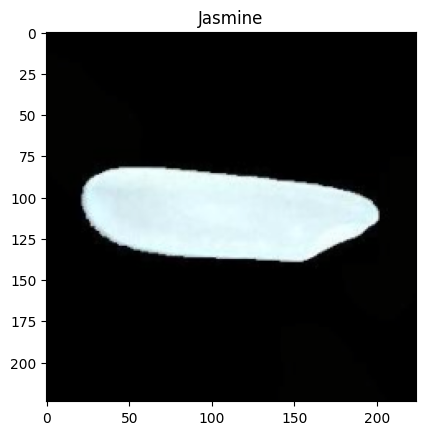

In [ ]:
# Get one batch of data
data_iterator = iter(train_loader)
images, labels = next(data_iterator)

# Show the first image in the batch
print(f"Label ID: {labels[0].item()}")
print(f"Label Name: {full_dataset.idx_to_class[labels[0].item()]}")

imshow(images[0], title=full_dataset.idx_to_class[labels[0].item()])

In [6]:
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim
import time
import copy
import gc
import timm
from tqdm import tqdm


In [7]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#
#
#

In [8]:

def get_modified_model(num_classes=5):
    # Loading Pre-trained MobileNetV3 Small
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)

    #changing last layer from conv feature block to linear layer for our classification task
    in_features = model.classifier[3].in_features

    model.classifier[3] = nn.Linear(in_features, num_classes)

    return model

# # Initialize
model = get_modified_model().to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 123MB/s]


In [ ]:
#Hyperparams
LR = 0.001
NUM_EPOCH = 3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    since = time.time()

    # Store results to plot later
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('-' * 10)

        # --- TRAINING PHASE ---
        model.train()  
        running_loss = 0.0
        running_corrects = 0

        for i ,(inputs, labels ) in enumerate(tqdm(train_loader)):
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # --- VALIDATION PHASE ---
        model.eval() 
        val_running_loss = 0.0
        val_running_corrects = 0
        
        with torch.no_grad():
            for i, (inputs, labels) in enumerate(tqdm(val_loader)):
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_running_corrects.double() / len(val_loader.dataset)

        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())

        print(f'Val   Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

        # Deep copy the model if it's the best one so far
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f"rice_model__epoch:{epoch+1}_loss:{val_loss:.2f}.pth")
            print("  -> Best model saved!")

        print("\n")

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history



In [ ]:
#Training
gc.collect()

# Release all unoccupied cached memory held by the CUDA caching allocator
if torch.cuda.is_available():
    torch.cuda.empty_cache()

#stopped training early as we were getting 99% accuracy
trained_model, training_history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCH)

Epoch 1/3
----------


100%|██████████| 938/938 [04:43<00:00,  3.31it/s]


Train Loss: 0.0297 Acc: 0.9907


100%|██████████| 235/235 [00:46<00:00,  5.03it/s]


Val   Loss: 0.0049 Acc: 0.9982
  -> Best model saved!


Epoch 2/3
----------


 12%|█▏        | 116/938 [00:38<04:35,  2.99it/s]


KeyboardInterrupt: 

In [ ]:
def plot_training_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.show()

# Run the plotter
plot_training_history(training_history)

NameError: name 'training_history' is not defined

In [9]:
!pip install executorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 134.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.1/538.1 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7

In [ ]:
!pip install torchao

In [11]:
import torch
import torch.nn as nn
from torch.export import export
from executorch.exir import to_edge
from executorch.exir import EdgeCompileConfig
from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner
# Quantization Imports (PT2E flow)
from torch.ao.quantization.quantize_pt2e import prepare_pt2e, convert_pt2e
from torch.ao.quantization.quantizer.xnnpack_quantizer import (
    XNNPACKQuantizer,
    get_symmetric_quantization_config, QuantizationConfig, QuantizationSpec
)
from tqdm import tqdm
from torch.ao.quantization.observer import HistogramObserver, MovingAverageMinMaxObserver, PerChannelMinMaxObserver, MinMaxObserver

Quantizing float32 model to int8 and exporting to executorch format **Post TRAINING QUANTIZATION**

In [10]:
import warnings
warnings.filterwarnings('ignore')
# comment this to see logs and warnings

In [20]:
import executorch.extension.pybindings.portable_lib
import executorch.kernels.quantized
from executorch.exir import to_edge_transform_and_lower
from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner

# Initialize and load weights
model = get_modified_model(num_classes=5)
model.load_state_dict(torch.load("rice_model__epoch_0_loss_0.01.pth", map_location="cpu"))
model.eval()

# Create a dummy input for the export tracer
example_input = (torch.randn(1, 3, 224, 224),)

#Capturing the graph using torch.export
print("Exporting model graph...")
exported_model = export(model, example_input)

quantizer = XNNPACKQuantizer()

######################### #THIS CONFIG GOT 66% accuracy 1.7MB model ################

global_config = get_symmetric_quantization_config(is_per_channel=True)
quantizer.set_global(global_config)

linear_config = get_symmetric_quantization_config(is_per_channel=True)
quantizer.set_module_type(nn.Linear, linear_config)


################################## #This config got worst accuracy model size 1.54MB #################

# config = get_symmetric_quantization_config(is_per_channel=False, is_qat=False)
# quantizer.set_global(config)

####################################### #THIS CONFIG GOT 99% accuracy 4.4MB model################
#instead of doing global quantization we will do per channel for conv layers \
#to preserve sensitive values and using common quantization for linear layer that are redundant
# global_config = get_symmetric_quantization_config(
#     is_per_channel=False,
#     is_qat=False
# )

# try:
#     # Trying per-channel for conv layers
#     conv_config = get_symmetric_quantization_config(
#         is_per_channel=True,
#         is_qat=False
#     )
#     quantizer.set_module_type(torch.nn.Conv2d, conv_config)

# except:
#     print("Per-channel not supported, using per-tensor for all layers")
## Set global config for all other layers
# quantizer.set_global(global_config)
#######################################################################



print("Preparing model for quantization...")
prepared_model = prepare_pt2e(exported_model.module(), quantizer)

# calibrating on train data
print("Calibrating ...")

try:
#
    print("found train loader batch 1")
    data_iter = iter(train_loader_batch_size_1)
    # trying with different steps to see its effect
    for i in tqdm(range(1000)):
        images, _ = next(data_iter)
        # The prepared_model (now a GraphModule) expects a single tensor input
        prepared_model(images)
except Exception as e:
    print(f"Warning: 'train_loader' not found. Using random noise for calibration (NOT RECOMMENDED for accuracy). {e}")

print("Converting to Int8...")
# conveting to int8
quantized_model_module = convert_pt2e(prepared_model)

print("Re-exporting quantized graph...")

quantized_exported_program = torch.export.export(quantized_model_module, example_input)

print("Lowering to ExecuTorch Edge IR...")

edge_program_manager = to_edge_transform_and_lower(
    quantized_exported_program,
    partitioner=[XnnpackPartitioner()]
)

executorch_program = edge_program_manager.to_executorch()
# Save the file
output_file = "rice_model_quantized.pte"
with open(output_file, "wb") as f:
    f.write(executorch_program.buffer)

print(f"SUCCESS! Model saved to {output_file}")
file_size = os.path.getsize(output_file) / (1024 * 1024)

print(f"✅ File size: {file_size:.2f} MB")

Exporting model graph...
Preparing model for quantization...
Calibrating ...
found train loader batch 1


100%|██████████| 1000/1000 [01:05<00:00, 15.23it/s]


Converting to Int8...
Re-exporting quantized graph...
Lowering to ExecuTorch Edge IR...
SUCCESS! Model saved to rice_model_quantized.pte
✅ File size: 1.65 MB


In [ ]:
import torch
from executorch.runtime import Runtime, Program, Method

print("Initializing ExecuTorch Runtime...")
runtime_instance = Runtime.get()

pte_path = "rice_model_quantized.pte"
try:
    program = runtime_instance.load_program(pte_path)
    print(f"Successfully loaded '{pte_path}'")
except Exception as e:
    print(f"Error loading model: {e}")


method_name = "forward"
try:
    method = program.load_method(method_name)
    print(f"Method '{method_name}' loaded ready for inference.")
except Exception as e:
    print(f"Error loading method '{method_name}': {e}")


input_tensor = torch.randn(1, 3, 224, 224)

try:
    outputs = method.execute([input_tensor])
    print("✅ Inference completed successfully!")
except Exception as e:
    print(f"❌ Inference failed: {e}")


[program.cpp:153] InternalConsistency verification requested but not available


Initializing ExecuTorch Runtime...
Successfully loaded 'rice_model_quantized.pte'
Method 'forward' loaded ready for inference.
✅ Inference completed successfully!


In [ ]:
!pip install scikit-learn seaborn tqdm

In [14]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from executorch.runtime import Runtime


In [15]:
# 4. Plot Confusion Matrix
# ---------------------------------------------------------
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Green for Baseline
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Original Float32 Model)')
    plt.show()

Evaluating baseline model

Evaluating on: cuda
Starting Inference on Validation Set (Float32 Model)...


Evaluating: 100%|██████████| 235/235 [00:40<00:00,  5.85it/s]



--- Baseline (Float32) Evaluation Results ---
Overall Accuracy: 99.82%

Detailed Classification Report:
              precision    recall  f1-score   support

     Arborio     0.9966    0.9966    0.9966      2928
     Basmati     0.9997    0.9980    0.9989      3054
      Ipsala     1.0000    1.0000    1.0000      2998
     Jasmine     0.9946    0.9993    0.9970      2968
   Karacadag     1.0000    0.9971    0.9985      3052

    accuracy                         0.9982     15000
   macro avg     0.9982    0.9982    0.9982     15000
weighted avg     0.9982    0.9982    0.9982     15000



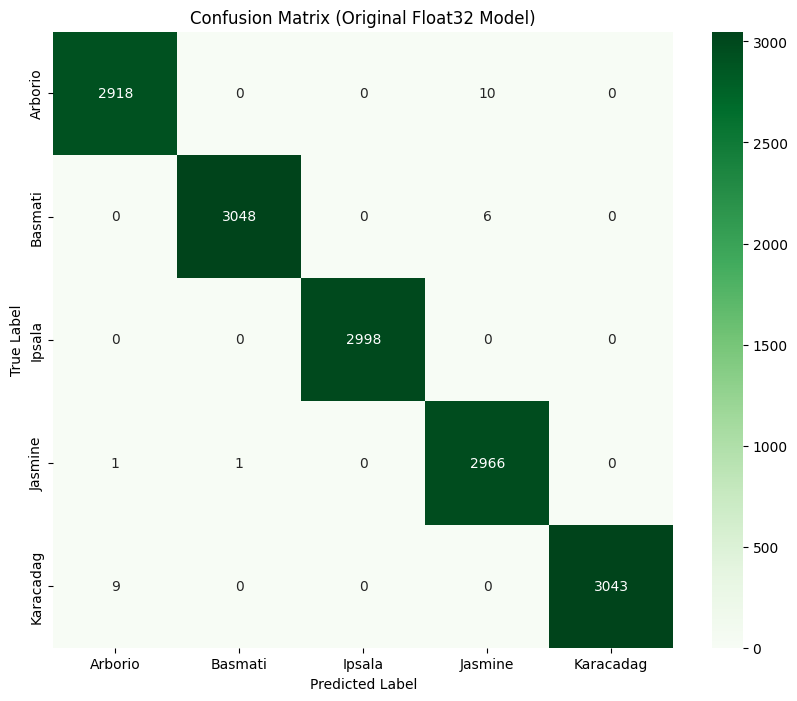

In [ ]:



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating on: {device}")

model = get_modified_model(num_classes=len(full_dataset.class_to_idx))

model.load_state_dict(torch.load("rice_model_effecientnet_v1.pth", map_location=device))

# Move to device and set to Evaluation mode (Critical!)
model.to(device)
model.eval()

# 2. Inference Loop
# ---------------------------------------------------------
y_true = []
y_pred = []

print("Starting Inference on Validation Set (Float32 Model)...")


with torch.no_grad()
    for inputs, labels in tqdm(val_loader, desc="Evaluating"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward Pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # Append to lists (Move to CPU first)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 3. Calculate Metrics
# ---------------------------------------------------------
print("\n--- Baseline (Float32) Evaluation Results ---")

# A. Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

# B. Detailed Report (Precision, Recall, F1-Score)
class_names = [full_dataset.idx_to_class[i] for i in range(len(full_dataset.class_to_idx))]

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\nDetailed Classification Report:")
print(report)



plot_confusion_matrix(y_true, y_pred, class_names)

Evaluating post training quantize model

[program.cpp:153] InternalConsistency verification requested but not available


Total Test Images: 15000
Loading rice_model_ptq_optimized_99.pte...
Model loaded successfully!
Starting Inference on Validation Set...


Evaluating: 100%|██████████| 15000/15000 [03:18<00:00, 75.69it/s]



--- Evaluation Results ---
rice_model_ptq_optimized_99.pte
Overall Accuracy: 99.73%

Detailed Classification Report:
              precision    recall  f1-score   support

     Arborio     0.9980    0.9957    0.9968      3016
     Basmati     0.9963    0.9980    0.9972      2998
      Ipsala     0.9997    1.0000    0.9998      2967
     Jasmine     0.9986    0.9929    0.9958      2975
   Karacadag     0.9938    0.9997    0.9967      3044

    accuracy                         0.9973     15000
   macro avg     0.9973    0.9973    0.9973     15000
weighted avg     0.9973    0.9973    0.9973     15000



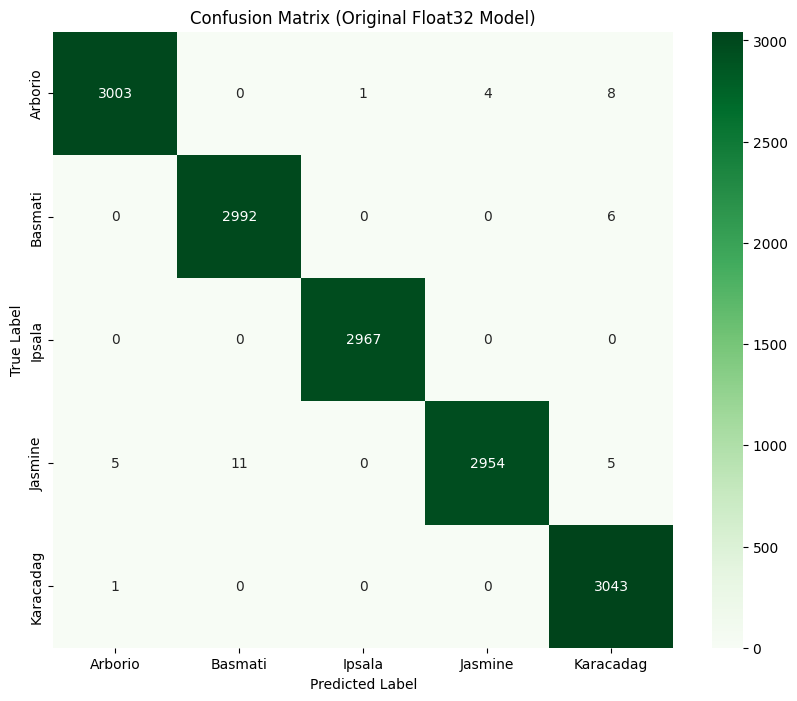

In [ ]:
#Model with 99% accuracy but slight bigger model size 4.4MB
from executorch.runtime import Runtime, Program, Method

eval_loader = DataLoader(val_subset, batch_size=1, shuffle=True, drop_last=True)

print(f"Total Test Images: {len(eval_loader)}")


pte_path = "rice_model_ptq_optimized_99.pte"
print(f"Loading {pte_path}...")

try:
    runtime_instance = Runtime.get()
    program = runtime_instance.load_program(pte_path)
    method_name = "forward"
    method = program.load_method(method_name)
    print("Model loaded successfully!")
except Exception as e:
    print(f"CRITICAL ERROR: Could not load model. {e}")


y_true = []
y_pred = []
inference_times = []

print("Starting Inference on Validation Set...")


for inputs, labels in tqdm(eval_loader, desc="Evaluating"):
    # inputs shape is [1, 3, 224, 224]
    outputs = method.execute([inputs])
    logits = outputs[0] 
    predicted_id = torch.argmax(logits, dim=1).item()
    y_pred.append(predicted_id)
    y_true.append(labels.item())


print("\n--- Evaluation Results ---")
print(f"{pte_path}")
# A. Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

# B. Detailed Report (Precision, Recall, F1-Score)
class_names = [full_dataset.idx_to_class[i] for i in range(len(full_dataset.class_to_idx))]

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\nDetailed Classification Report:")
print(report)



plot_confusion_matrix(y_true, y_pred, class_names)

[program.cpp:153] InternalConsistency verification requested but not available


Total Test Images: 15000
Loading rice_model_quantized_66.pte...
Model loaded successfully!
Starting Inference on Validation Set...


Evaluating: 100%|██████████| 15000/15000 [02:55<00:00, 85.27it/s]



--- Evaluation Results ---
rice_model_quantized_66.pte
Overall Accuracy: 66.29%

Detailed Classification Report:
              precision    recall  f1-score   support

     Arborio     1.0000    0.0392    0.0754      3010
     Basmati     0.5776    0.9940    0.7307      3006
      Ipsala     1.0000    0.4083    0.5798      3042
     Jasmine     0.4824    0.8919    0.6262      2988
   Karacadag     0.9959    0.9922    0.9941      2954

    accuracy                         0.6629     15000
   macro avg     0.8112    0.6651    0.6012     15000
weighted avg     0.8115    0.6629    0.5997     15000



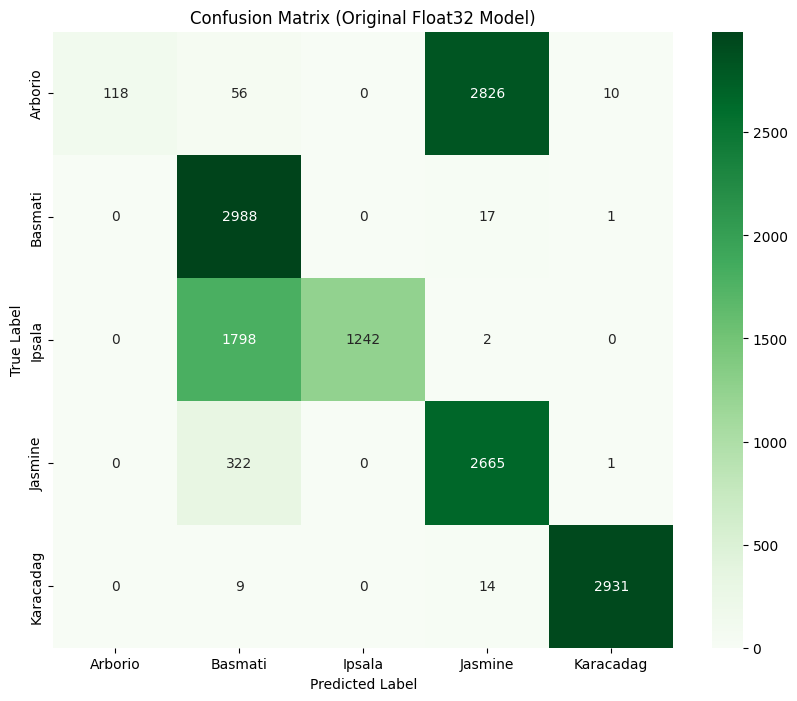

In [ ]:
""" Model with 66% - global_config = get_symmetric_quantization_config(is_per_channel=True)
quantizer.set_global(global_config)

linear_config = get_symmetric_quantization_config(is_per_channel=True)
quantizer.set_module_type(nn.Linear, linear_config) """
###
from executorch.runtime import Runtime, Program, Method

eval_loader = DataLoader(val_subset, batch_size=1, shuffle=True, drop_last=True)

print(f"Total Test Images: {len(eval_loader)}")


pte_path = "rice_model_quantized_66.pte"
print(f"Loading {pte_path}...")

try:
    runtime_instance = Runtime.get()
    program = runtime_instance.load_program(pte_path)
    method_name = "forward"
    method = program.load_method(method_name)
    print("Model loaded successfully!")
except Exception as e:
    print(f"CRITICAL ERROR: Could not load model. {e}")

y_true = []
y_pred = []
inference_times = []

print("Starting Inference on Validation Set...")

for inputs, labels in tqdm(eval_loader, desc="Evaluating"):
    outputs = method.execute([inputs])
    logits = outputs[0] 
    predicted_id = torch.argmax(logits, dim=1).item()

    y_pred.append(predicted_id)
    y_true.append(labels.item())


print("\n--- Evaluation Results ---")
print(f"{pte_path}")
# A. Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

# B. Detailed Report (Precision, Recall, F1-Score)
class_names = [full_dataset.idx_to_class[i] for i in range(len(full_dataset.class_to_idx))]

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\nDetailed Classification Report:")
print(report)



plot_confusion_matrix(y_true, y_pred, class_names)

In [ ]:
!ls -lh .

total 230M
drwxr-xr-x 3 root root 4.0K Dec 15 16:13 rice-image-dataset
-rw-r--r-- 1 root root 220M Dec 15 16:13 rice-image-dataset.zip
-rw-r--r-- 1 root root 6.0M Dec 15 16:18 rice_model__epoch_0_loss_0.01.pth
-rw-r--r-- 1 root root 4.2M Dec 15 16:39 rice_model_ptq_optimized.pte
drwxr-xr-x 1 root root 4.0K Dec  9 14:42 sample_data
